# Test Notebook for dataset transformation

In [18]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy import ndimage as ndi
from phenobench import PhenoBench
from phenobench.visualization import draw_semantics, draw_instances, draw_bboxes
from pprint import pprint

In [ ]:
train_data = PhenoBench("../../data/PhenoBench", 
                        target_types=["semantics", "plant_instances", "leaf_instances", "plant_bboxes", "leaf_bboxes"])

In [ ]:
# def masks_to_boxes(seg, ignore=0, min_area=1, connectivity=2):
#     """Returns (N, 5) float32: [class_id, x_min, y_min, width, height]."""
#     seg = np.asarray(seg)
#     ignore = np.atleast_1d(ignore)
#     struct = ndi.generate_binary_structure(2, connectivity)

#     boxes = []
#     for cls in np.unique(seg):
#         if np.isin(cls, ignore):
#             continue
#         labels, _ = ndi.label(seg == cls, structure=struct)
#         for lab, sl in enumerate(ndi.find_objects(labels), start=1):
#             if min_area > 1 and (labels[sl] == lab).sum() < min_area:
#                 continue
#             y, x = sl
#             boxes.append((cls, x.start, y.start, x.stop - x.start, y.stop - y.start))

#     return np.array(boxes, dtype=np.float32).reshape(-1, 5)

In [ ]:
def masks_to_boxes(seg, ignore=0, min_area=1, connectivity=2):
    """Bounding boxes from a semantic segmentation map via connected components.

    seg           (H, W) integer array of class IDs.
    ignore        class ID(s) not to box (0 = soil in PhenoBench).
    min_area      drop components with fewer mask pixels than this.
    connectivity  2 = 8-neighbourhood (default), 1 = 4-neighbourhood.

    Returns a list of dicts in the PhenoBench devkit format:
        {"label": int, "corner": (x_min, y_min), "center": (cx, cy),
         "width": int, "height": int}
    ready for phenobench.visualization.visualize_bounding_boxes.

    Follows the devkit's closed-interval convention (evaluation/auxiliary/
    convert.py): x_min/x_max are the first and last occupied pixel, and
    width = x_max - x_min, so an object spanning 15 pixels has width 14.
    center = round((x_min + x_max) / 2).

    Caveat: connected components are not instances. Two touching objects of the
    same class become one box; one object split by occlusion becomes two.
    """
    seg = np.asarray(seg)
    ignore = np.atleast_1d(ignore)
    struct = ndi.generate_binary_structure(2, connectivity)

    boxes = []
    for cls in np.unique(seg):
        if np.isin(cls, ignore):
            continue
        labels, _ = ndi.label(seg == cls, structure=struct)
        for lab, sl in enumerate(ndi.find_objects(labels), start=1):
            if min_area > 1 and (labels[sl] == lab).sum() < min_area:
                continue
            y, x = sl
            x_min, x_max = x.start, x.stop - 1          # inclusive
            y_min, y_max = y.start, y.stop - 1          # inclusive
            boxes.append({
                "label": int(cls),
                "corner": (x_min, y_min),
                "center": (round((x_min + x_max) / 2), round((y_min + y_max) / 2)),
                "width": x_max - x_min,
                "height": y_max - y_min,
            })

    return boxes

In [26]:
def masks_to_labels(seg, ignore=0):
    """Sorted list of class IDs present in a semantic segmentation map.

    seg     (H, W) integer array of class IDs.
    ignore  class ID(s) to leave out (0 = soil in PhenoBench).

    Returns a list of plain Python ints, e.g. [1, 2].
    """
    labels = np.unique(np.asarray(seg))
    return labels[~np.isin(labels, ignore)].tolist()

    # ###for top-k ranked comparison
    # counts = np.bincount(seg.ravel(), minlength=num_classes)
    # counts[0] = 0
    # ranking = np.argsort(-counts)          # -> [2, 1], counts [90000, 1]

In [8]:
print("The first entry contains the following fields:")
pprint([f"{k} -> {type(v)}" for k, v in train_data[0].items()])

The first entry contains the following fields:
["image_name -> <class 'str'>",
 "image -> <class 'PIL.Image.Image'>",
 "semantics -> <class 'numpy.ndarray'>",
 "plant_instances -> <class 'numpy.ndarray'>",
 "leaf_instances -> <class 'numpy.ndarray'>",
 "plant_bboxes -> <class 'list'>",
 "leaf_bboxes -> <class 'list'>"]


In [30]:
idx = 2

example_sem_gt = train_data[idx]["semantics"]

Text(0.5, 1.0, 'BBox Conversion')

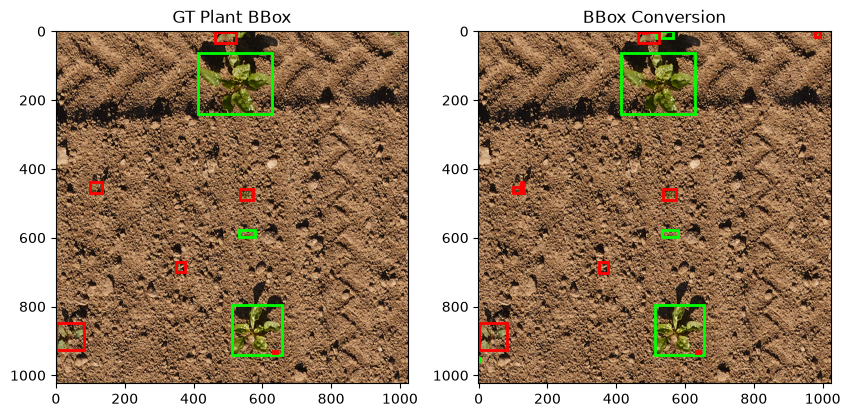

In [31]:
# bbox conversion
box_conversion = masks_to_boxes(example_sem_gt)

# Plot creation
fig, ax = plt.subplots(ncols=2, nrows=1, figsize=(10, 8))
draw_bboxes(ax[0], train_data[idx]["image"], train_data[idx]["plant_bboxes"])
ax[0].set_title("GT Plant BBox")
draw_bboxes(ax[1], train_data[idx]["image"], box_conversion)
ax[1].set_title("BBox Conversion")

In [32]:
predicted_labels = masks_to_labels(example_sem_gt)
predicted_labels

[1, 2]